In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score


# Create X first

In [ ]:

X, _ = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=1.0,
    random_state=42
)

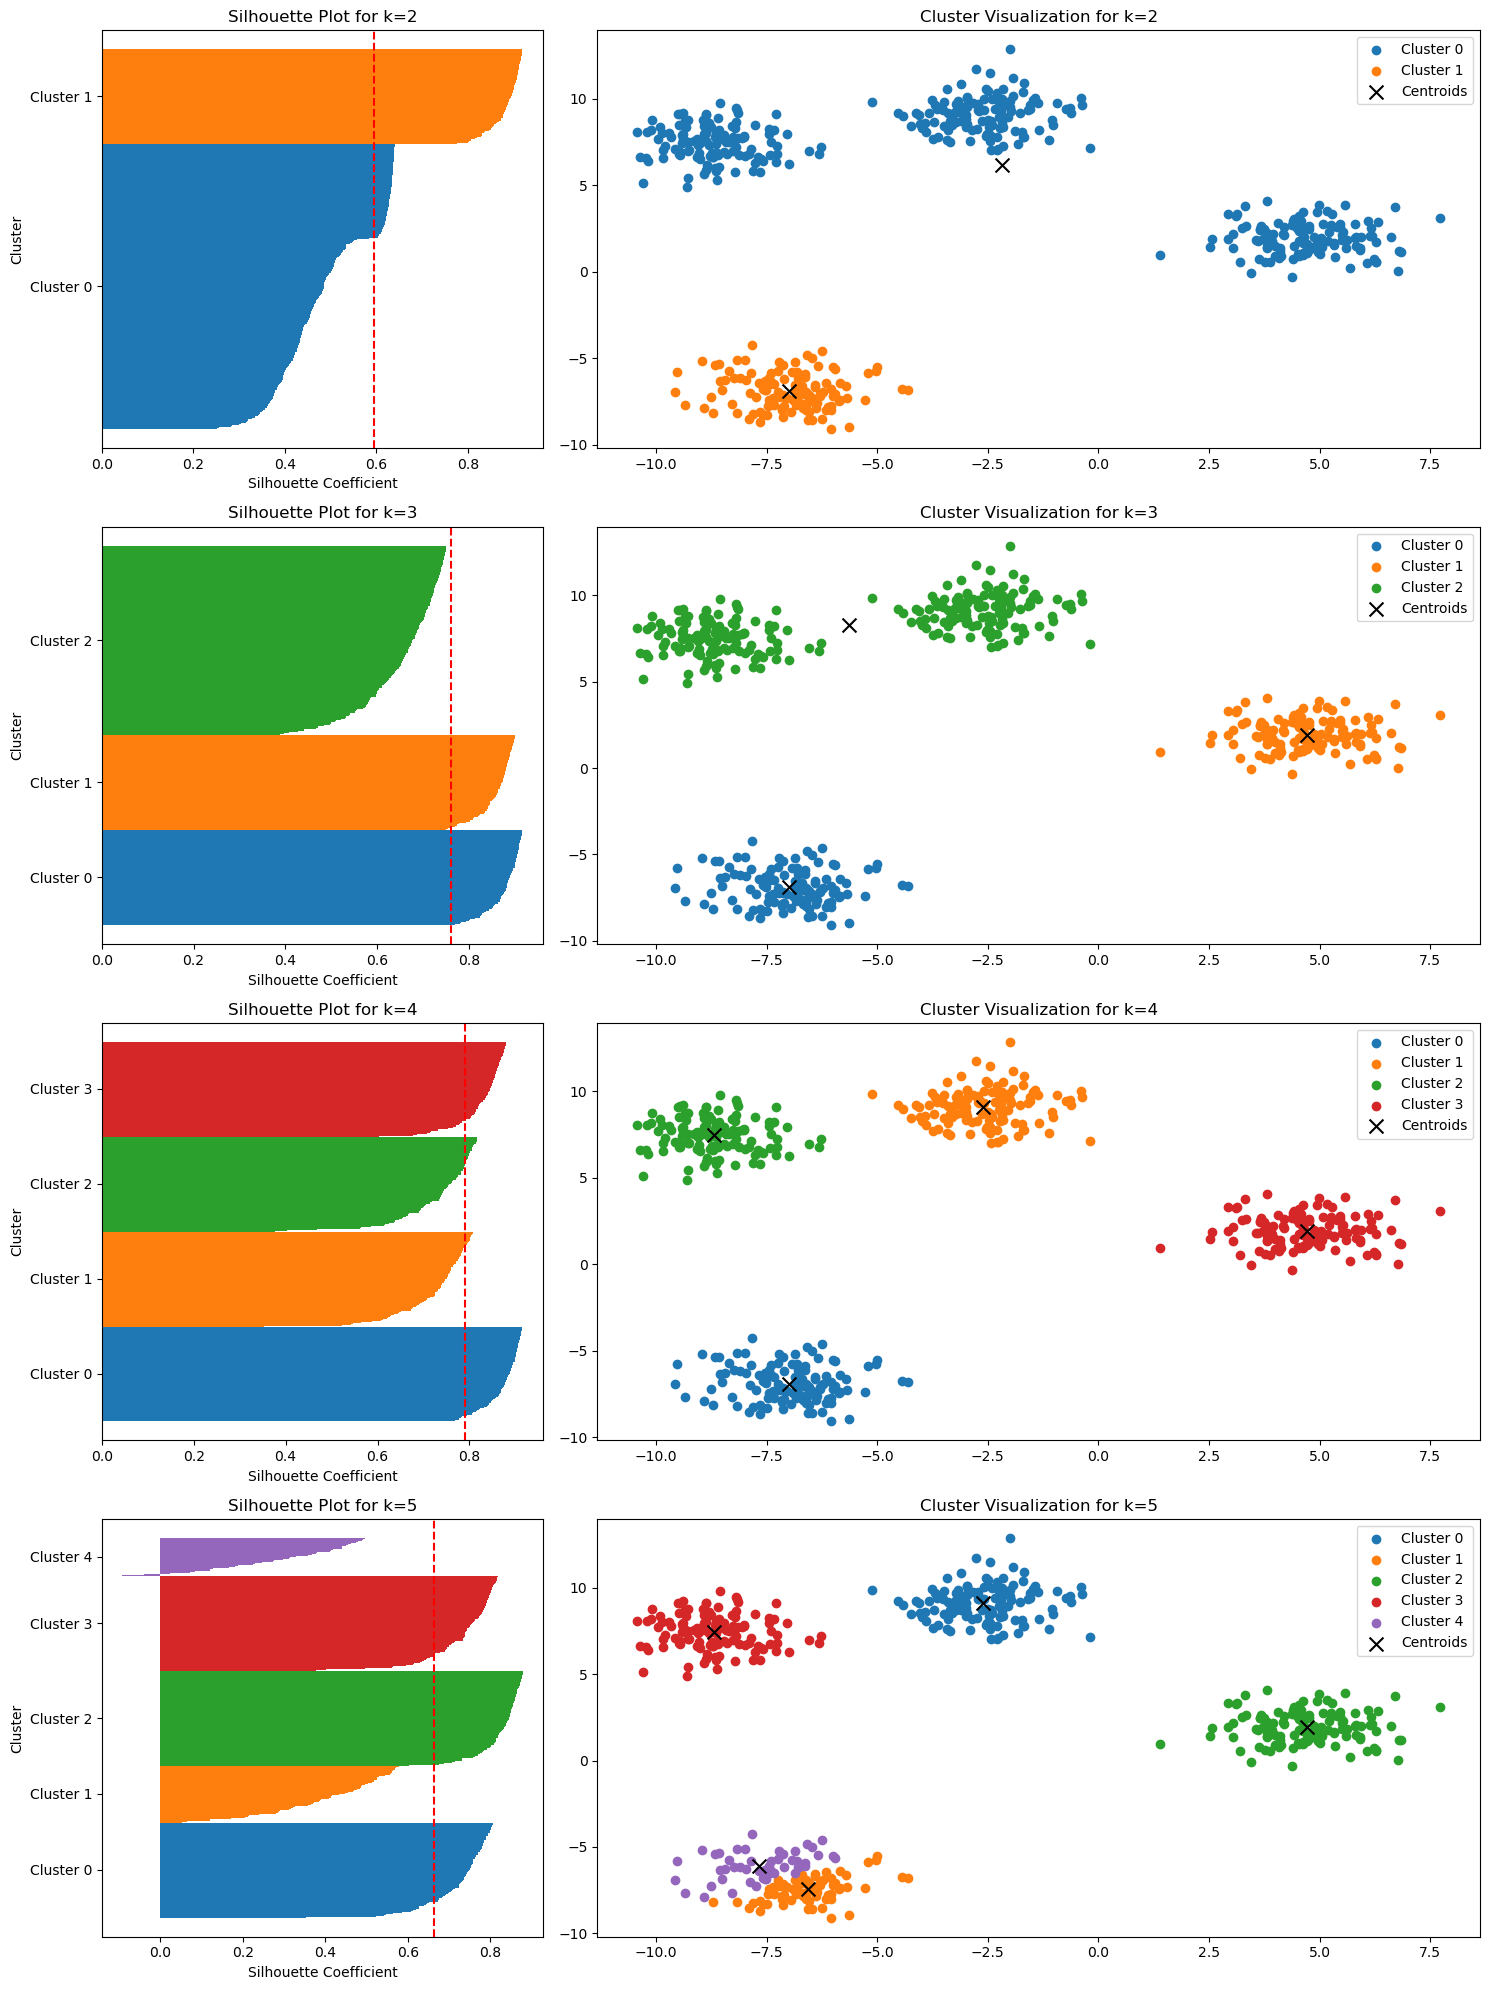

In [31]:

from sklearn.metrics import silhouette_samples, silhouette_score
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# Setting up the subplot grid
fig = plt.figure(figsize=(15, 20))
gs = gridspec.GridSpec(4, 2, width_ratios=[1, 2])

# Creating silhouette and scatter plots for different values of k (2, 3, 4, 5)
for i, k in enumerate([2, 3, 4, 5]):

    # Clustering with K-means
    kmeans = KMeans(
        n_init=10,
        n_clusters=k,
        random_state=10
    )

    cluster_labels = kmeans.fit_predict(X)

    # Silhouette values
    silhouette_vals = silhouette_samples(X, cluster_labels)
    avg_score = silhouette_score(X, cluster_labels)

    # --------------------------------------------------
    # Silhouette Plot
    # --------------------------------------------------
    ax1 = plt.subplot(gs[i, 0])

    y_lower, y_upper = 0, 0
    yticks = []

    for j, cluster in enumerate(np.unique(cluster_labels)):

        cluster_silhouette_vals = silhouette_vals[
            cluster_labels == cluster
        ]

        cluster_silhouette_vals.sort()

        y_upper += len(cluster_silhouette_vals)

        ax1.barh(
            range(y_lower, y_upper),
            cluster_silhouette_vals,
            edgecolor='none',
            height=1
        )

        yticks.append((y_lower + y_upper) / 2)

        y_lower += len(cluster_silhouette_vals)

    ax1.axvline(
        avg_score,
        color='red',
        linestyle='--'
    )

    ax1.set_yticks(yticks)

    ax1.set_yticklabels(
        [f'Cluster {x}' for x in np.unique(cluster_labels)]
    )

    ax1.set_ylabel('Cluster')
    ax1.set_xlabel('Silhouette Coefficient')
    ax1.set_title(f'Silhouette Plot for k={k}')

    # --------------------------------------------------
    # Scatter Plot
    # --------------------------------------------------
    ax2 = plt.subplot(gs[i, 1])

    for j in np.unique(cluster_labels):
        ax2.scatter(
            X[cluster_labels == j, 0],
            X[cluster_labels == j, 1],
            label=f'Cluster {j}'
        )

    ax2.scatter(
        kmeans.cluster_centers_[:, 0],
        kmeans.cluster_centers_[:, 1],
        s=100,
        c='black',
        marker='x',
        label='Centroids'
    )

    ax2.set_title(
        f'Cluster Visualization for k={k}'
    )

    ax2.legend()

plt.tight_layout()
plt.show()

--------

--------

--------

--------

# Another 

In [5]:

# Generate Sample Dataset

X, _ = make_blobs(
    n_samples=500,
    n_features=2,
    centers=4,
    cluster_std=1.0,
    random_state=42
)

In [7]:
# Apply K-Means



k = 4

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X)

In [9]:
# Compute Silhouette Metrics


avg_silhouette = silhouette_score(X, cluster_labels)
sample_silhouette_values = silhouette_samples(X, cluster_labels)

print(f"Average Silhouette Score: {avg_silhouette:.3f}")

Average Silhouette Score: 0.791


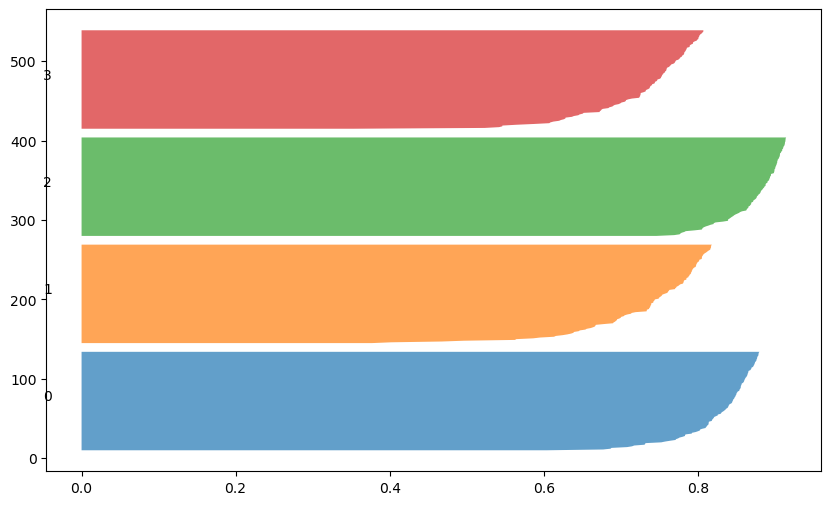

In [11]:
# Create Silhouette Plot


fig, ax = plt.subplots(figsize=(10, 6))

y_lower = 10

for i in range(k):

    # Silhouette values for cluster i
    ith_cluster_values = sample_silhouette_values[
        cluster_labels == i
    ]

    ith_cluster_values.sort()

    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_values,
        alpha=0.7
    )

    # Cluster label
    ax.text(
        -0.05,
        y_lower + 0.5 * size_cluster_i,
        str(i)
    )

    y_lower = y_upper + 10

In [12]:
# Average Silhouette Line (Red Dashed Line)


ax.axvline(
    x=avg_silhouette,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Average Score = {avg_silhouette:.3f}"
)

In [15]:
# Formatting

ax.set_title("Silhouette Plot for K-Means Clustering")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")

ax.set_yticks([])
ax.set_xlim([-0.2, 1])

ax.legend()
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

-----

----

------

------

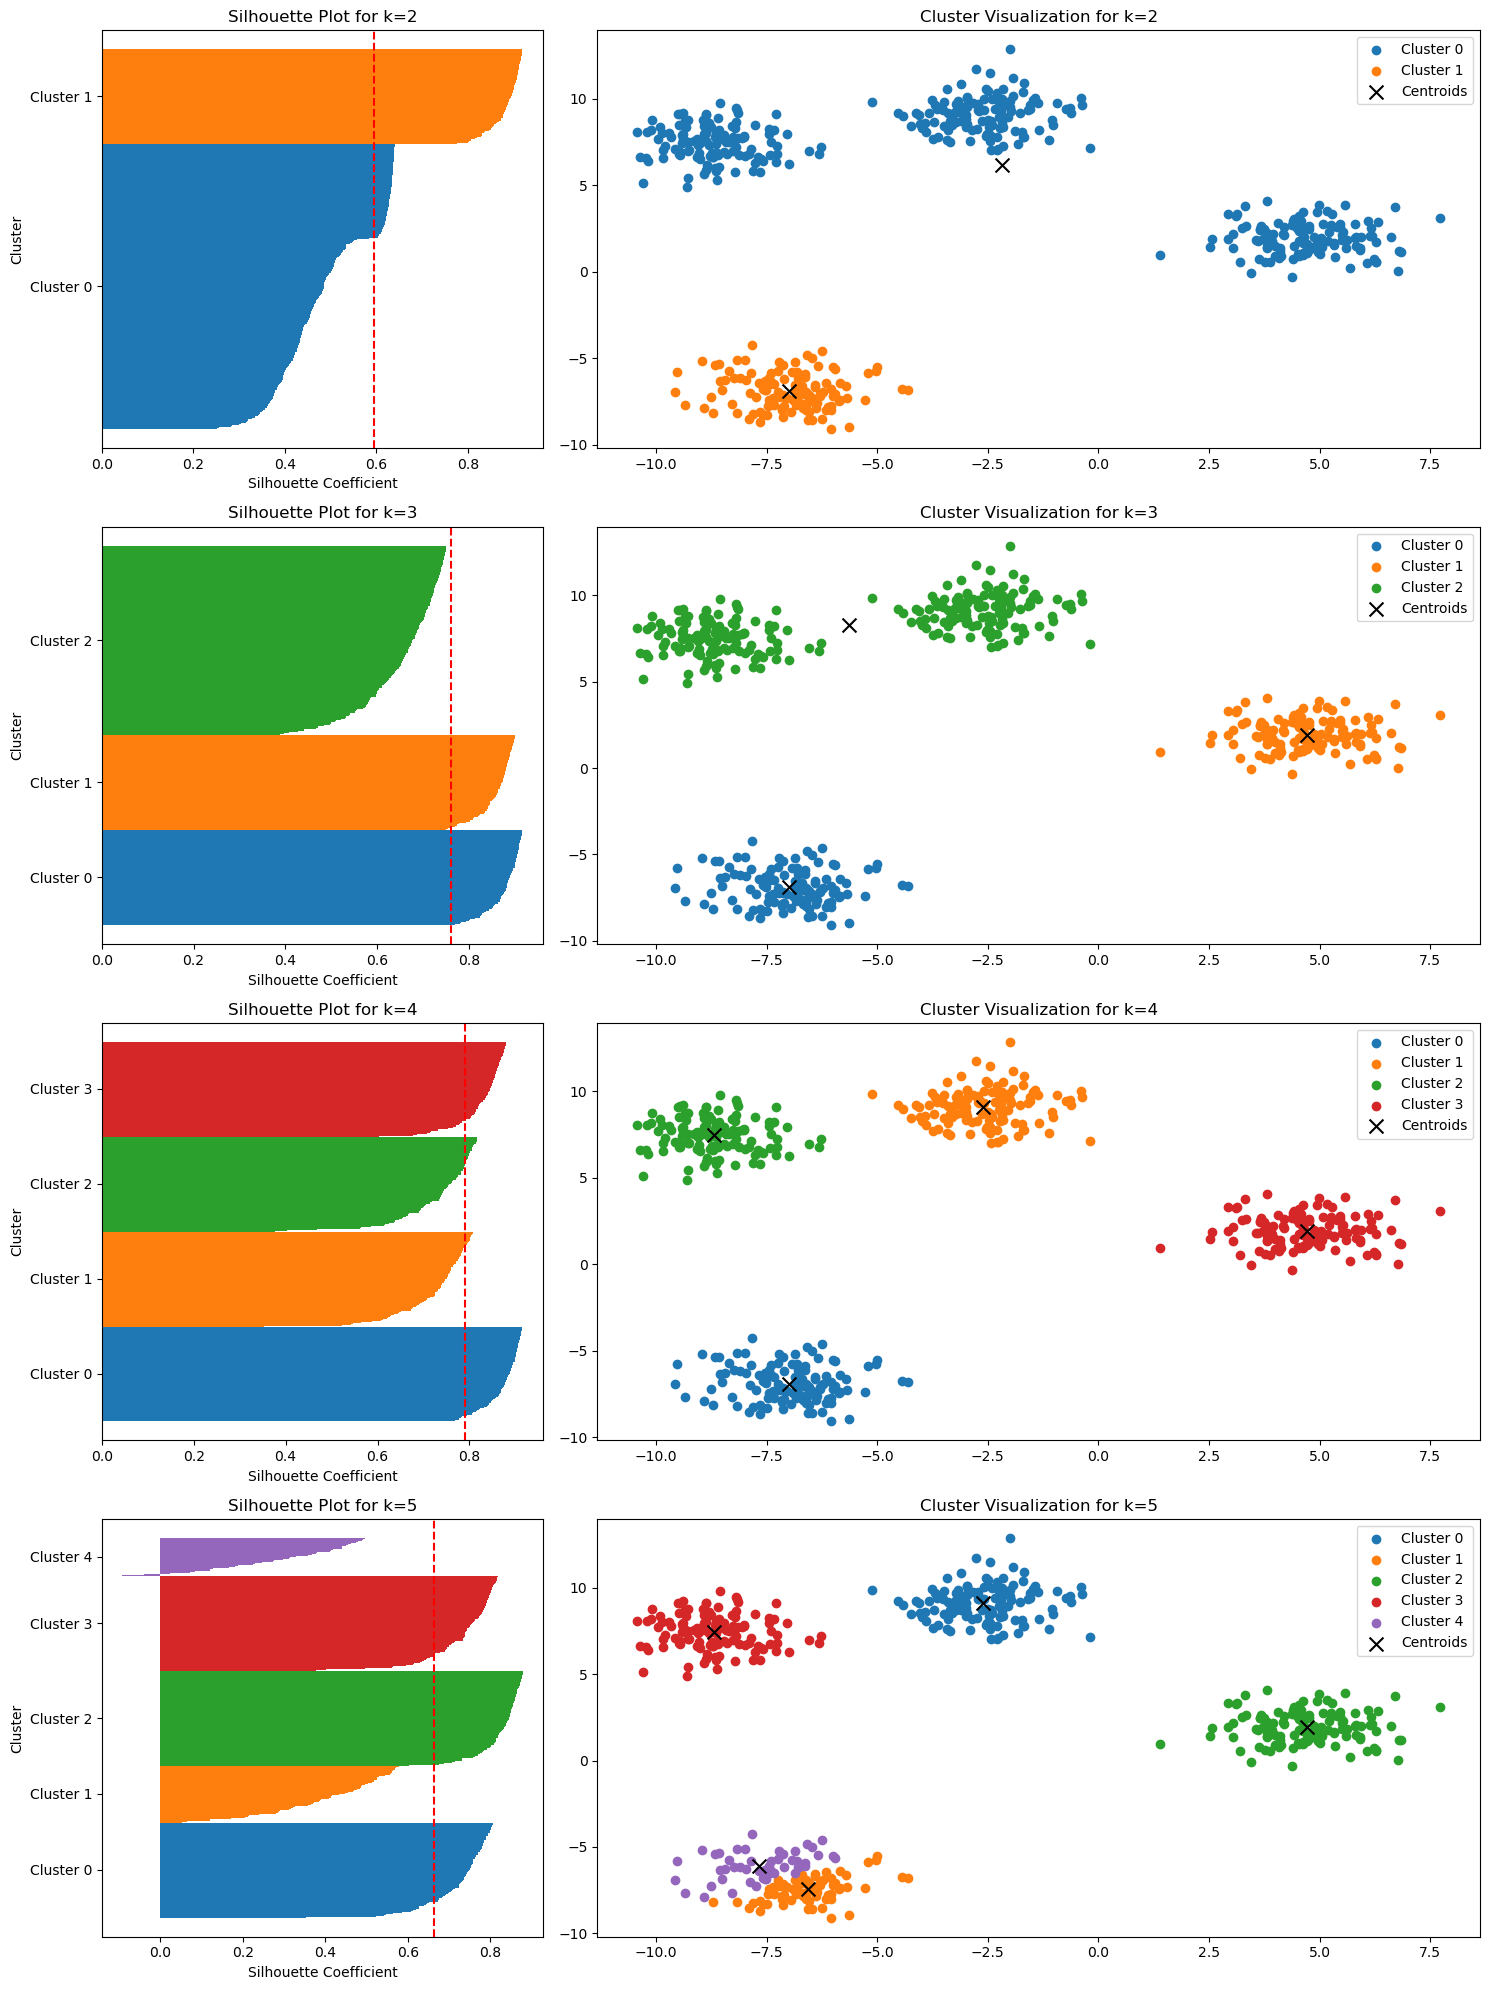